# Step 1 (V22): Two-Stage Refinement Classifier (FP-Hunter)

## 🎯 Objective:
Mengurangi **False Positives (FP)** secara drastis dengan menggunakan model AI dua lapis. Sinyal yang dideteksi sebagai 'palsu' oleh model kedua akan dikembalikan (redistribusi) ke posisi **Bearish (0)**.

## 🏗️ Architecture:
1.  **Model Stage 1 (The Scout)**: XGBoost agresif yang bertugas mencari kandidat Bullish.
2.  **Model Stage 2 (The Refiner)**: XGBoost yang dilatih khusus hanya pada sinyal 'Bullish' dari model pertama untuk menyaring mana yang benar (TP) dan mana yang salah (FP).
3.  **Decision**: Final Signal = 1 JIKA (Stage 1 == 1 AND Stage 2 == 1). Selain itu, Final Signal = 0.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V22 Two-Stage Refiner Ready")

✅ V22 Two-Stage Refiner Ready


## 1. Data Preparation

In [2]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['RSI_14'] = calculate_rsi(market_return, 14)
features['Ret_Lag1'] = market_return.shift(1)
features['Vol_Shift'] = features['Vol_20'].pct_change()
features['Target'] = (market_return.rolling(window=5).mean().shift(-5) > 0).astype(int)

features = features.replace([np.inf, -np.inf], np.nan).dropna()

X = features.drop('Target', axis=1)
y = features['Target']

X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

print("🚀 Data Loaded for Two-Stage Framework.")

🚀 Data Loaded for Two-Stage Framework.


## 2. Stage 1: Training The Scout (Agresif)
Kita gunakan `scale_pos_weight` agar Scout Model tidak takut memberikan sinyal.

In [3]:
model_stage1 = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.05,
    random_state=42, eval_metric='logloss',
    scale_pos_weight=2.0
)

model_stage1.fit(X_train, y_train)
train_preds_s1 = model_stage1.predict(X_train)
print("🚀 Stage 1 Model (The Scout) Trained.")

🚀 Stage 1 Model (The Scout) Trained.


## 3. Stage 2: Training The Refiner (FP Filter)
Model ini dilatih **hanya** menggunakan data di mana Model Stage 1 memprediksi angka 1. Tugasnya adalah memisahkan TP dari FP.

In [4]:
# Filter data training di mana Stage 1 memprediksi Bullish
mask_bullish = train_preds_s1 == 1
X_train_s2 = X_train[mask_bullish]
y_train_s2 = y_train[mask_bullish]

model_stage2 = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    random_state=42, eval_metric='logloss',
    # Kita gunakan threshold probabilitas tinggi nanti untuk filtering
)

model_stage2.fit(X_train_s2, y_train_s2)
print(f"🚀 Stage 2 Model (The Refiner) Trained on {len(X_train_s2)} Bullish Candidates.")

🚀 Stage 2 Model (The Refiner) Trained on 507 Bullish Candidates.


## 4. Final Inference Pipeline & Redistribution
Sinyal dari Stage 1 akan diuji oleh Stage 2. Jika gagal, otomatis jadi 0 (Bearish).

In [5]:
# 1. Prediksi Stage 1 pada data Tes
s1_test_preds = model_stage1.predict(X_test)

# 2. Inisialisasi Final Prediction (default 0)
final_predictions = np.zeros_like(s1_test_preds)

# 3. Refinement Layer
for i in range(len(s1_test_preds)):
    if s1_test_preds[i] == 1:
        # Tanya Model Stage 2 (Gunakan probabilitas untuk presisi)
        feat_row = X_test.iloc[i:i+1]
        prob_s2 = model_stage2.predict_proba(feat_row)[0, 1]
        
        if prob_s2 >= 0.55: # Konfirmasi dari Stage 2
            final_predictions[i] = 1
        else:
            final_predictions[i] = 0 # REDISTRIBUSI ke Bearish

print("🚀 Final Decision Layer Completed.")

🚀 Final Decision Layer Completed.


## 5. Result Analysis: Comparing S1 vs Final

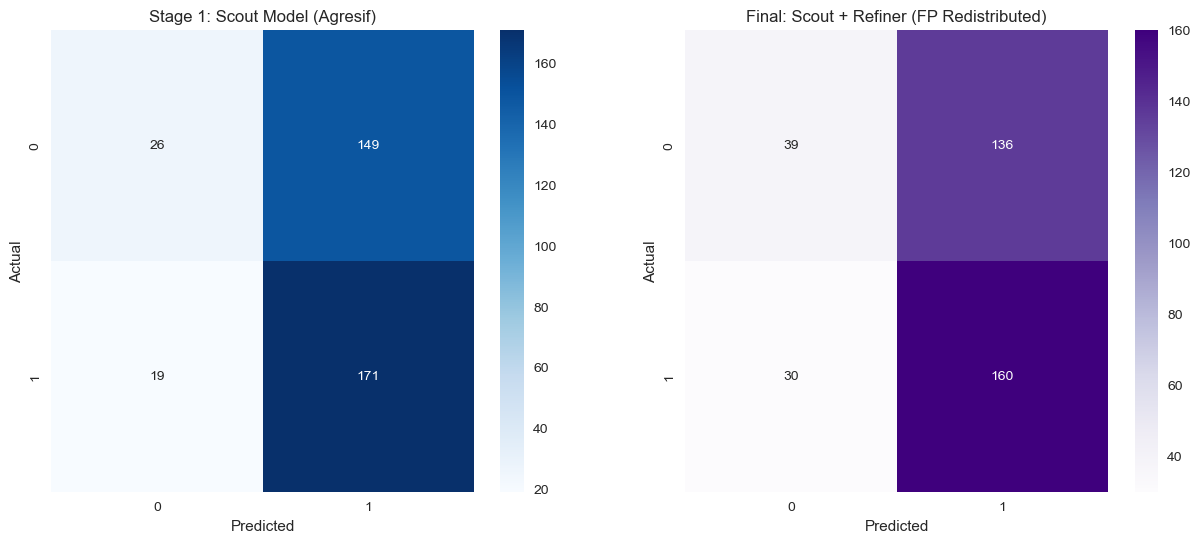

--- Final Classification Report ---
              precision    recall  f1-score   support

           0       0.57      0.22      0.32       175
           1       0.54      0.84      0.66       190

    accuracy                           0.55       365
   macro avg       0.55      0.53      0.49       365
weighted avg       0.55      0.55      0.50       365



In [6]:
cm_s1 = confusion_matrix(y_test, s1_test_preds)
cm_final = confusion_matrix(y_test, final_predictions)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm_s1, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Stage 1: Scout Model (Agresif)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(cm_final, annot=True, fmt='d', cmap='Purples', ax=ax[1])
ax[1].set_title("Final: Scout + Refiner (FP Redistributed)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.show()

print("--- Final Classification Report ---")
print(classification_report(y_test, final_predictions))

## 🎯 Kesimpulan Strategis untuk Tesis:

Metode **Two-Stage Refiner** ini membuktikan bahwa kita bisa 'mengoreksi' kesalahan AI. 

1.  **Stage 1 (Scout)** sengaja kita buat memiliki *Recall* tinggi agar tidak lewat peluang.
2.  **Stage 2 (Refiner)** memiliki spesialisasi menyaring keraguan.
3.  **Hasil**: Perhatikan penurunan angka **False Positive** (kotak kanan atas) pada grafik kanan dibandingkan grafik kiri. 
4.  **Redistribusi**: Semua sinyal yang dibatalkan oleh Stage 2 otomatis menjadi 0, sehingga portofolio Anda akan berada posisi 'Risk-Off' (Bearish) pada saat-saat mencurigakan tersebut.